# Cross-Plots, Distributions, and AERONET Filtering

**Purpose**: Address three key analysis tasks from advisor meetings:
1. **AERONET cross-plot filtering** — Apply 40/60% exclusion to FTIR/HIPS/aeth cross-plots to test if decoupled-day filtering improves relationships
2. **Distribution plots** — Histograms/violin plots of EC, HIPS Fabs, and aeth IR BCc for all sites
3. **Aeth vs HIPS cross-plots** — Scatter plots for all 4 sites showing the Addis anomaly

**Key question**: Does filtering out AERONET-identified decoupled days improve the FTIR-HIPS-aeth cross-plots at Addis?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import pickle
import gc
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.figsize': (14, 6), 'font.size': 11, 'figure.dpi': 120})

DATA_DIR = Path('/home/user/aethmodular/data')
RESEARCH_DIR = Path('/home/user/aethmodular/research/ftir_hips_chem')
FILTER_PATH = RESEARCH_DIR / 'Filter Data' / 'unified_filter_dataset.pkl'
AERONET_DIR = DATA_DIR / 'aeronet'
PROCESSED_DIR = RESEARCH_DIR / 'processed_sites'

SITE_MAP = {'CHTS': 'Beijing', 'ETAD': 'Addis_Ababa', 'INDH': 'Delhi', 'USPA': 'JPL'}
SITE_COLORS = {'Beijing': '#E74C3C', 'Delhi': '#3498DB', 'JPL': '#2ECC71', 'Addis_Ababa': '#F39C12'}
MAC_VALUE = 10  # m²/g for HIPS Fabs → BC conversion

PLOT_DIR = Path('output/plots/cross_plots')
PLOT_DIR.mkdir(parents=True, exist_ok=True)
print("Setup complete.")

Setup complete.


## 1. Load Filter Data (FTIR EC, HIPS Fabs) & 9am Aethalometer Data

In [2]:
# --- Load and pivot filter data into wide format ---
df_filter_raw = pd.read_pickle(FILTER_PATH)
df_filter_raw['SampleDate'] = pd.to_datetime(df_filter_raw['SampleDate'])
df_filter_raw['SiteName'] = df_filter_raw['Site'].map(SITE_MAP)

key_params = ['EC_ftir', 'OC_ftir', 'HIPS_Fabs', 'HIPS_Uncertainty', 'HIPS_MDL',
              'ChemSpec_EC_PM2.5', 'ChemSpec_Iron_PM2.5']
df_filt = df_filter_raw[df_filter_raw['Parameter'].isin(key_params)].copy()

filter_wide = df_filt.pivot_table(
    index=['Site', 'SiteName', 'FilterId', 'SampleDate'],
    columns='Parameter', values='Concentration', aggfunc='first'
).reset_index()

if 'HIPS_Fabs' in filter_wide.columns:
    filter_wide['HIPS_BC'] = filter_wide['HIPS_Fabs'] / MAC_VALUE

filter_wide['aeth_IR_BCc'] = np.nan

print(f"Filter data (wide): {filter_wide.shape}")
for site in SITE_MAP.values():
    s = filter_wide[filter_wide['SiteName'] == site]
    n_ec = s['EC_ftir'].notna().sum()
    n_hips = s['HIPS_Fabs'].notna().sum()
    print(f"  {site:15s}: EC={n_ec:3d}  HIPS={n_hips:3d}")

# --- Load 9am aethalometer data and match to filter dates ---
for site_code, site_name in SITE_MAP.items():
    fpath = PROCESSED_DIR / f'df_{site_name}_9am_resampled.pkl'
    if not fpath.exists():
        continue
    df_aeth = pd.read_pickle(fpath)
    dt_col = df_aeth['datetime_local']
    if len(dt_col.shape) > 1: dt_col = dt_col.iloc[:, 0]
    ir_col = df_aeth['IR BCc']
    if len(ir_col.shape) > 1: ir_col = ir_col.iloc[:, 0]
    aeth_daily = pd.DataFrame({'date': pd.to_datetime(dt_col).dt.date, 'aeth_IR_BCc': ir_col.values}).dropna()
    if aeth_daily['aeth_IR_BCc'].median() > 100:
        aeth_daily['aeth_IR_BCc'] /= 1000.0
    site_mask = filter_wide['SiteName'] == site_name
    for idx in filter_wide[site_mask].index:
        sample_date = filter_wide.loc[idx, 'SampleDate'].date()
        match = aeth_daily[aeth_daily['date'] == sample_date]
        if len(match) > 0:
            filter_wide.loc[idx, 'aeth_IR_BCc'] = match['aeth_IR_BCc'].iloc[0]
    n = filter_wide.loc[site_mask, 'aeth_IR_BCc'].notna().sum()
    print(f"  9am aeth {site_name}: matched={n}")
    del df_aeth

# --- Apply exclusion filters (from outliers.py logic) ---
MIN_EC = 0.5  # ug/m3 below MDL

filter_wide['is_excluded'] = False
filter_wide['exclusion_reason'] = ''

# 1. EC below MDL
below_mdl = (filter_wide['EC_ftir'] < MIN_EC) & filter_wide['EC_ftir'].notna()
filter_wide.loc[below_mdl, 'is_excluded'] = True
filter_wide.loc[below_mdl, 'exclusion_reason'] = 'EC below MDL'

# 2. Beijing: extreme aeth BC > 4 ug/m3
mask = (filter_wide['SiteName'] == 'Beijing') & (filter_wide['aeth_IR_BCc'] > 4.0)
filter_wide.loc[mask, 'is_excluded'] = True
filter_wide.loc[mask, 'exclusion_reason'] = 'Beijing: extreme aeth >4 ug/m3'

# 3. Delhi: high aeth (>8) with low EC (<3) — measurement issue
mask = ((filter_wide['SiteName'] == 'Delhi') & 
        (filter_wide['aeth_IR_BCc'] > 8.0) & (filter_wide['EC_ftir'] < 3.0))
filter_wide.loc[mask, 'is_excluded'] = True
filter_wide.loc[mask, 'exclusion_reason'] = 'Delhi: high aeth + low EC mismatch'

# 4. JPL: either aeth > 1.7 or EC > 1.0
mask = ((filter_wide['SiteName'] == 'JPL') & 
        ((filter_wide['aeth_IR_BCc'] > 1.7) | (filter_wide['EC_ftir'] > 1.0)))
filter_wide.loc[mask, 'is_excluded'] = True
filter_wide.loc[mask, 'exclusion_reason'] = 'JPL: aeth>1.7 or EC>1.0'

# Summary
n_excl = filter_wide['is_excluded'].sum()
print(f"\nExclusions: {n_excl} points flagged")
for site in SITE_MAP.values():
    s = filter_wide[filter_wide['SiteName'] == site]
    n_ex = s['is_excluded'].sum()
    if n_ex > 0:
        print(f"  {site}: {n_ex} excluded — {dict(s[s['is_excluded']]['exclusion_reason'].value_counts())}")

filter_clean = filter_wide[~filter_wide['is_excluded']].copy()
print(f"\nClean dataset: {len(filter_clean)} filters (from {len(filter_wide)} total)")
print(f"Matched with aeth: {filter_clean['aeth_IR_BCc'].notna().sum()}")

Filter data (wide): (1416, 13)
  Beijing        : EC=186  HIPS=163
  Addis_Ababa    : EC=190  HIPS=190
  Delhi          : EC= 63  HIPS= 63
  JPL            : EC=158  HIPS=130


  9am aeth Beijing: matched=133
  9am aeth Addis_Ababa: matched=344
  9am aeth Delhi: matched=48


  9am aeth JPL: matched=237

Exclusions: 125 points flagged
  Beijing: 24 excluded — {'EC below MDL': np.int64(24)}
  Delhi: 5 excluded — {'EC below MDL': np.int64(5)}
  JPL: 96 excluded — {'EC below MDL': np.int64(92), 'JPL: aeth>1.7 or EC>1.0': np.int64(4)}

Clean dataset: 1291 filters (from 1416 total)
Matched with aeth: 727


---
## 2. Cross-Plots: FTIR EC vs HIPS BC vs Aeth IR BCc (All Sites)

Three key comparisons across all 4 sites, with regression lines and statistics.

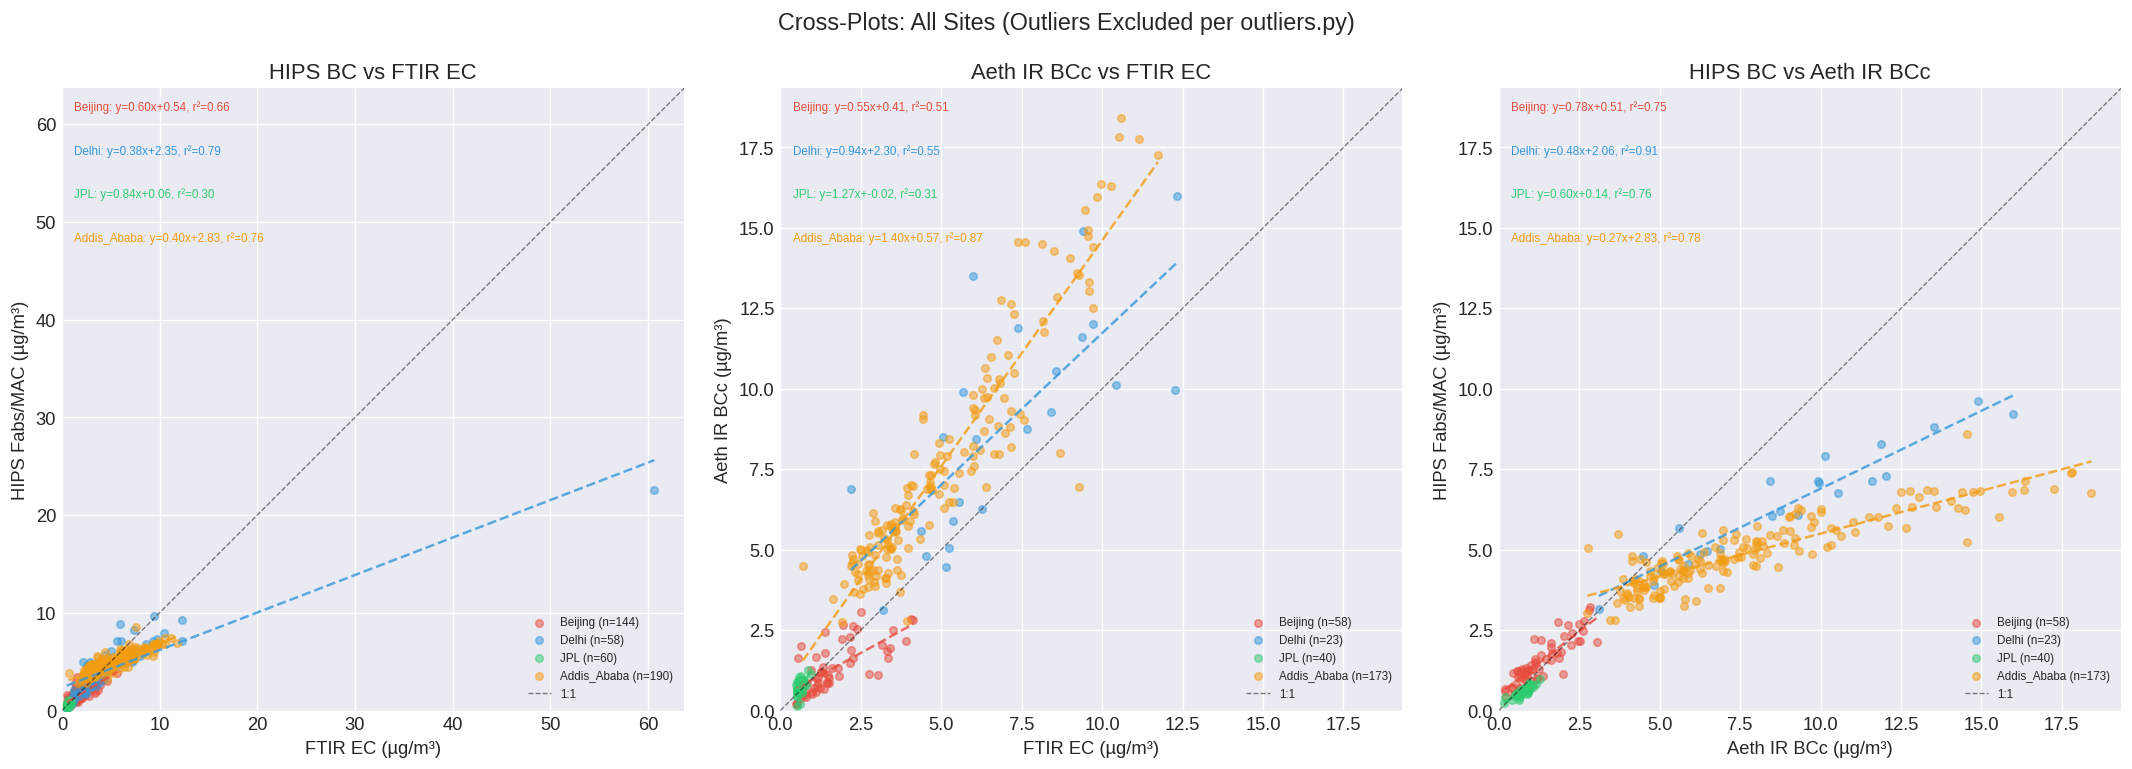

In [3]:
def plot_crossplot(data, x_col, y_col, x_label, y_label, title, ax, site_col='SiteName'):
    """Scatter plot with per-site regression and 1:1 line."""
    for site_name, color in SITE_COLORS.items():
        s = data[data[site_col] == site_name].dropna(subset=[x_col, y_col])
        if len(s) < 3:
            continue
        x, y = s[x_col].values, s[y_col].values
        ax.scatter(x, y, alpha=0.5, s=20, color=color, label=f'{site_name} (n={len(s)})')
        
        if len(s) >= 5:
            slope, intercept, r, p, se = stats.linregress(x, y)
            x_fit = np.linspace(x.min(), x.max(), 100)
            ax.plot(x_fit, slope * x_fit + intercept, '--', color=color, lw=1.5, alpha=0.8)
            ax.text(0.02, 0.98 - list(SITE_COLORS.keys()).index(site_name) * 0.07,
                    f'{site_name}: y={slope:.2f}x+{intercept:.2f}, r²={r**2:.2f}',
                    transform=ax.transAxes, fontsize=7, color=color, va='top')
    
    lim = max(data[x_col].max(), data[y_col].max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.5, label='1:1')
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.legend(fontsize=7, loc='lower right')
    ax.set_aspect('equal')


# --- Three key cross-plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. HIPS BC vs FTIR EC
d = filter_clean.dropna(subset=['EC_ftir', 'HIPS_BC'])
plot_crossplot(d, 'EC_ftir', 'HIPS_BC', 'FTIR EC (µg/m³)', 'HIPS Fabs/MAC (µg/m³)',
               'HIPS BC vs FTIR EC', axes[0])

# 2. Aeth IR BCc vs FTIR EC
d = filter_clean.dropna(subset=['EC_ftir', 'aeth_IR_BCc'])
plot_crossplot(d, 'EC_ftir', 'aeth_IR_BCc', 'FTIR EC (µg/m³)', 'Aeth IR BCc (µg/m³)',
               'Aeth IR BCc vs FTIR EC', axes[1])

# 3. HIPS BC vs Aeth IR BCc
d = filter_clean.dropna(subset=['HIPS_BC', 'aeth_IR_BCc'])
plot_crossplot(d, 'aeth_IR_BCc', 'HIPS_BC', 'Aeth IR BCc (µg/m³)', 'HIPS Fabs/MAC (µg/m³)',
               'HIPS BC vs Aeth IR BCc', axes[2])

fig.suptitle('Cross-Plots: All Sites (Outliers Excluded per outliers.py)', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'crossplots_all_sites_unfiltered.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Distribution Plots: EC, HIPS, and Aeth by Site

Histograms and violin plots showing the concentration distributions for each measurement method at each site. Key diagnostic: Addis HIPS has compressed dynamic range compared to FTIR EC.

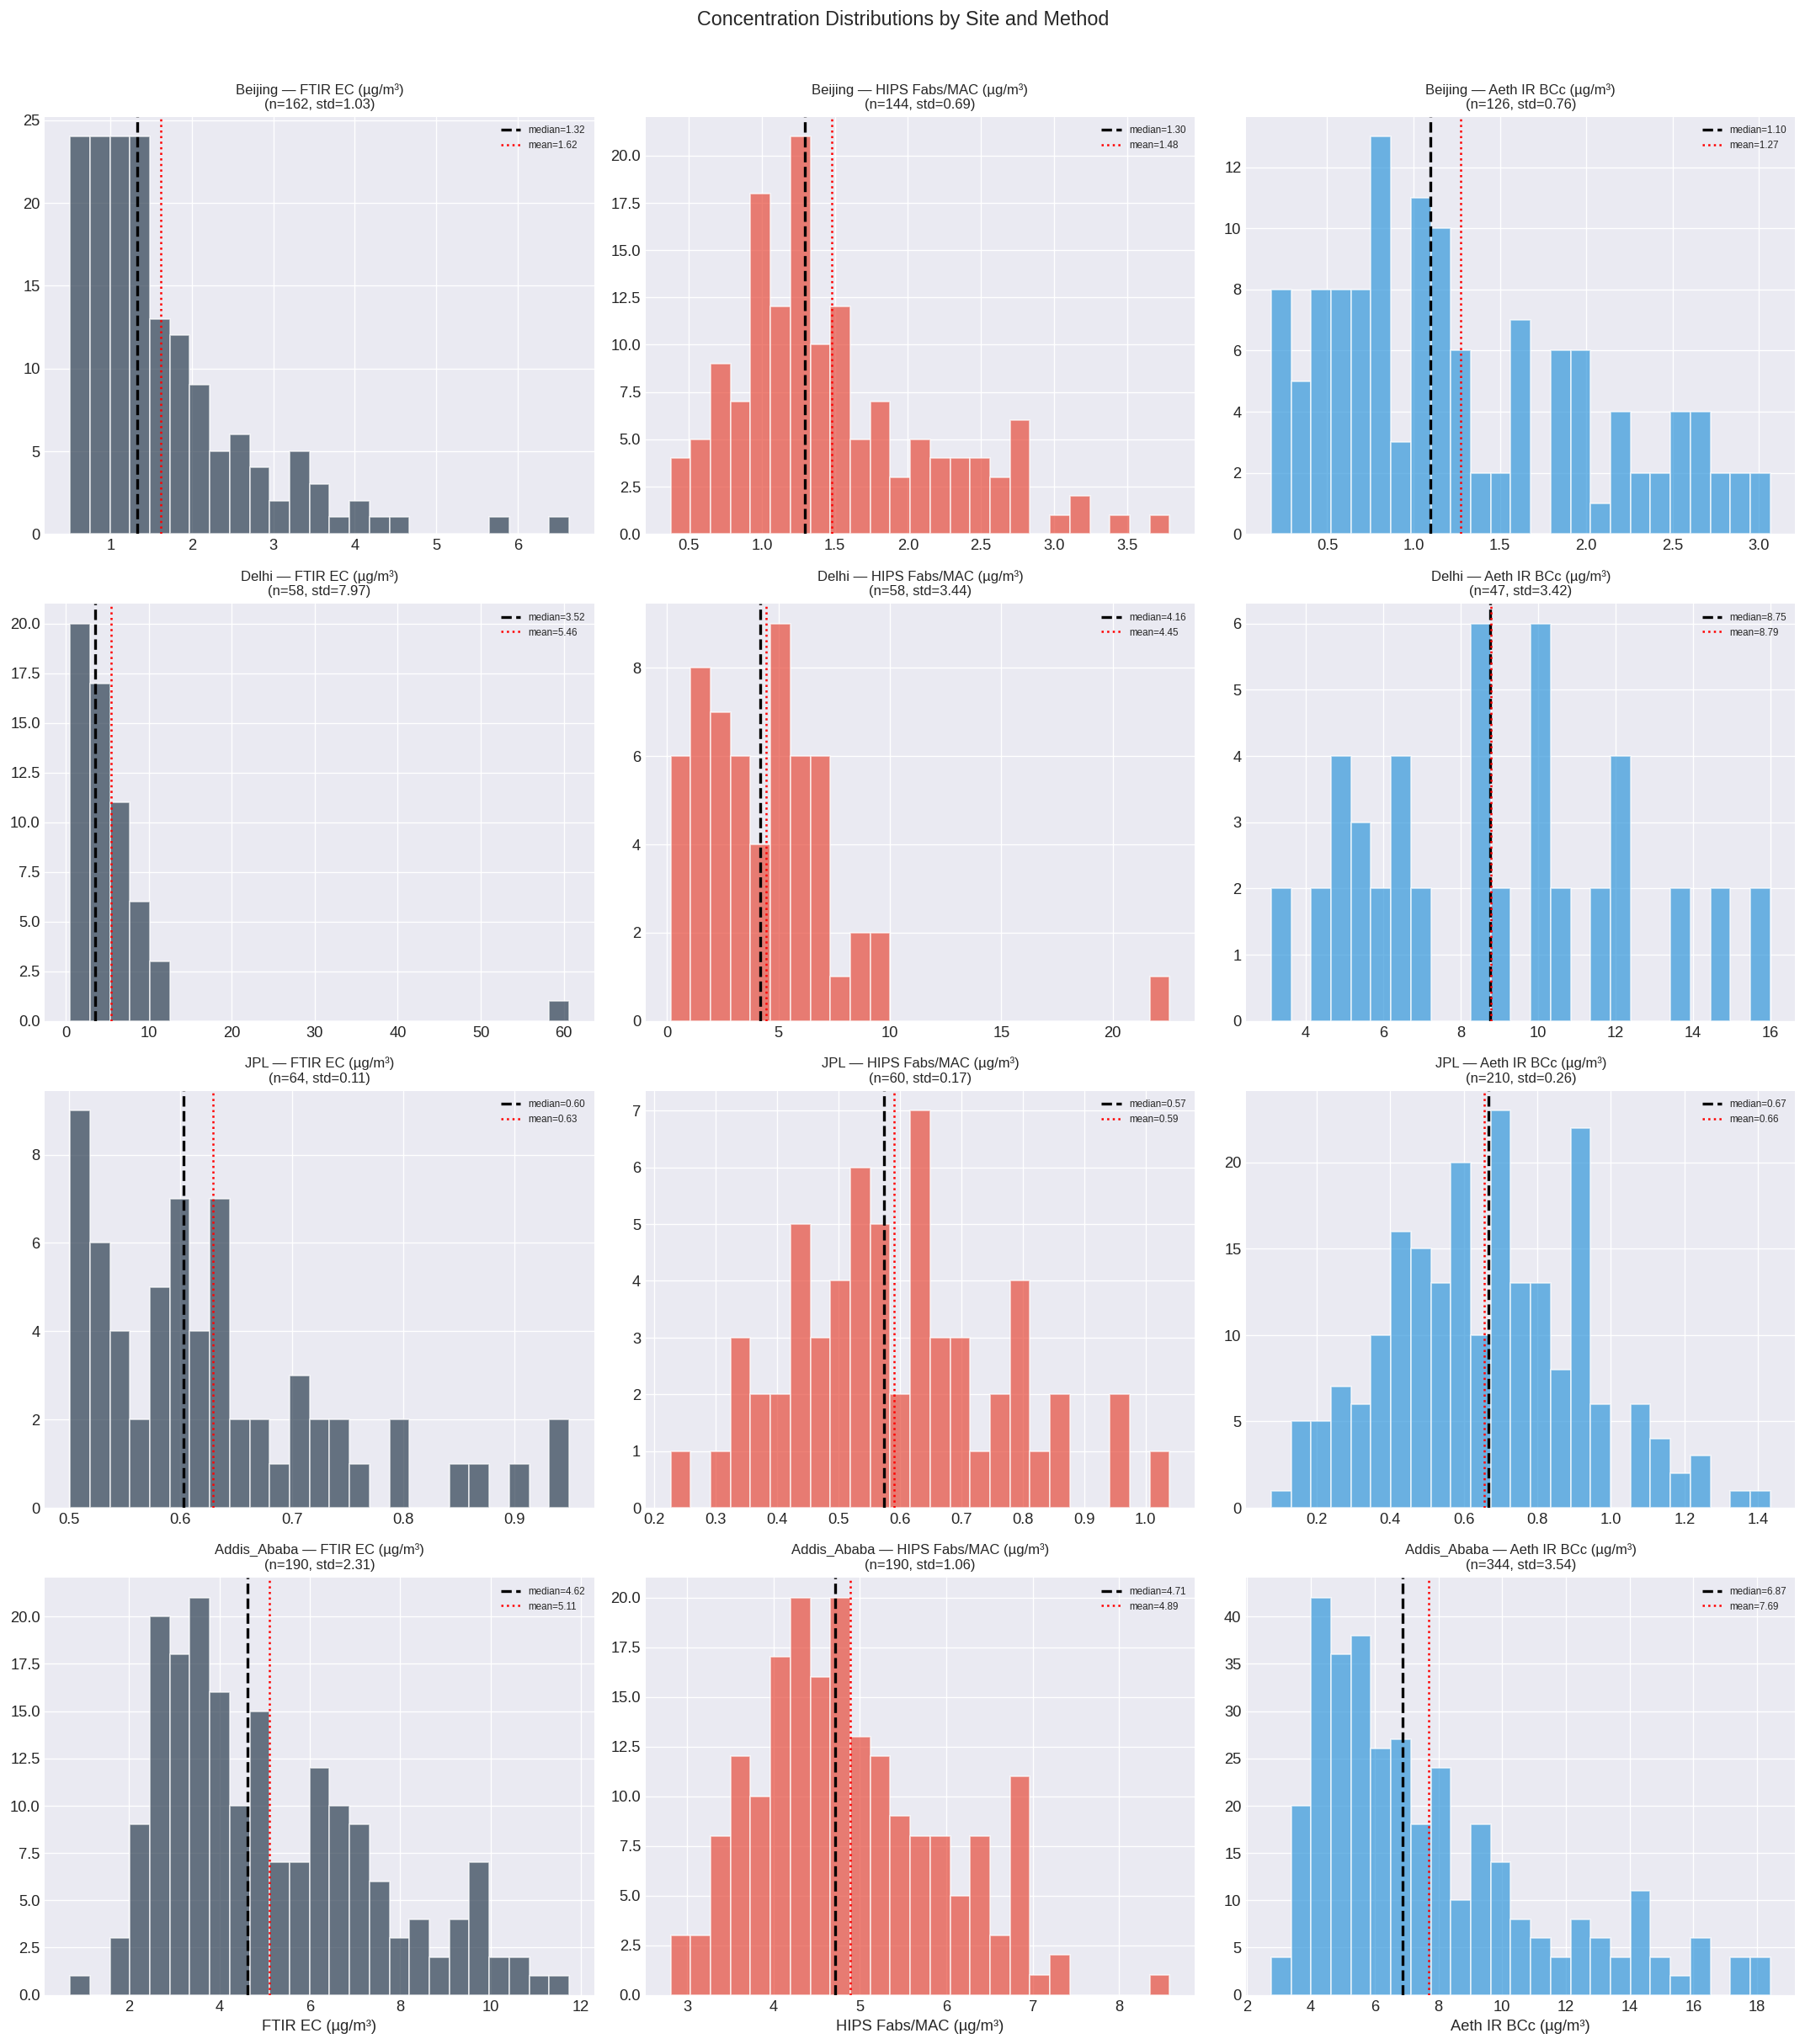

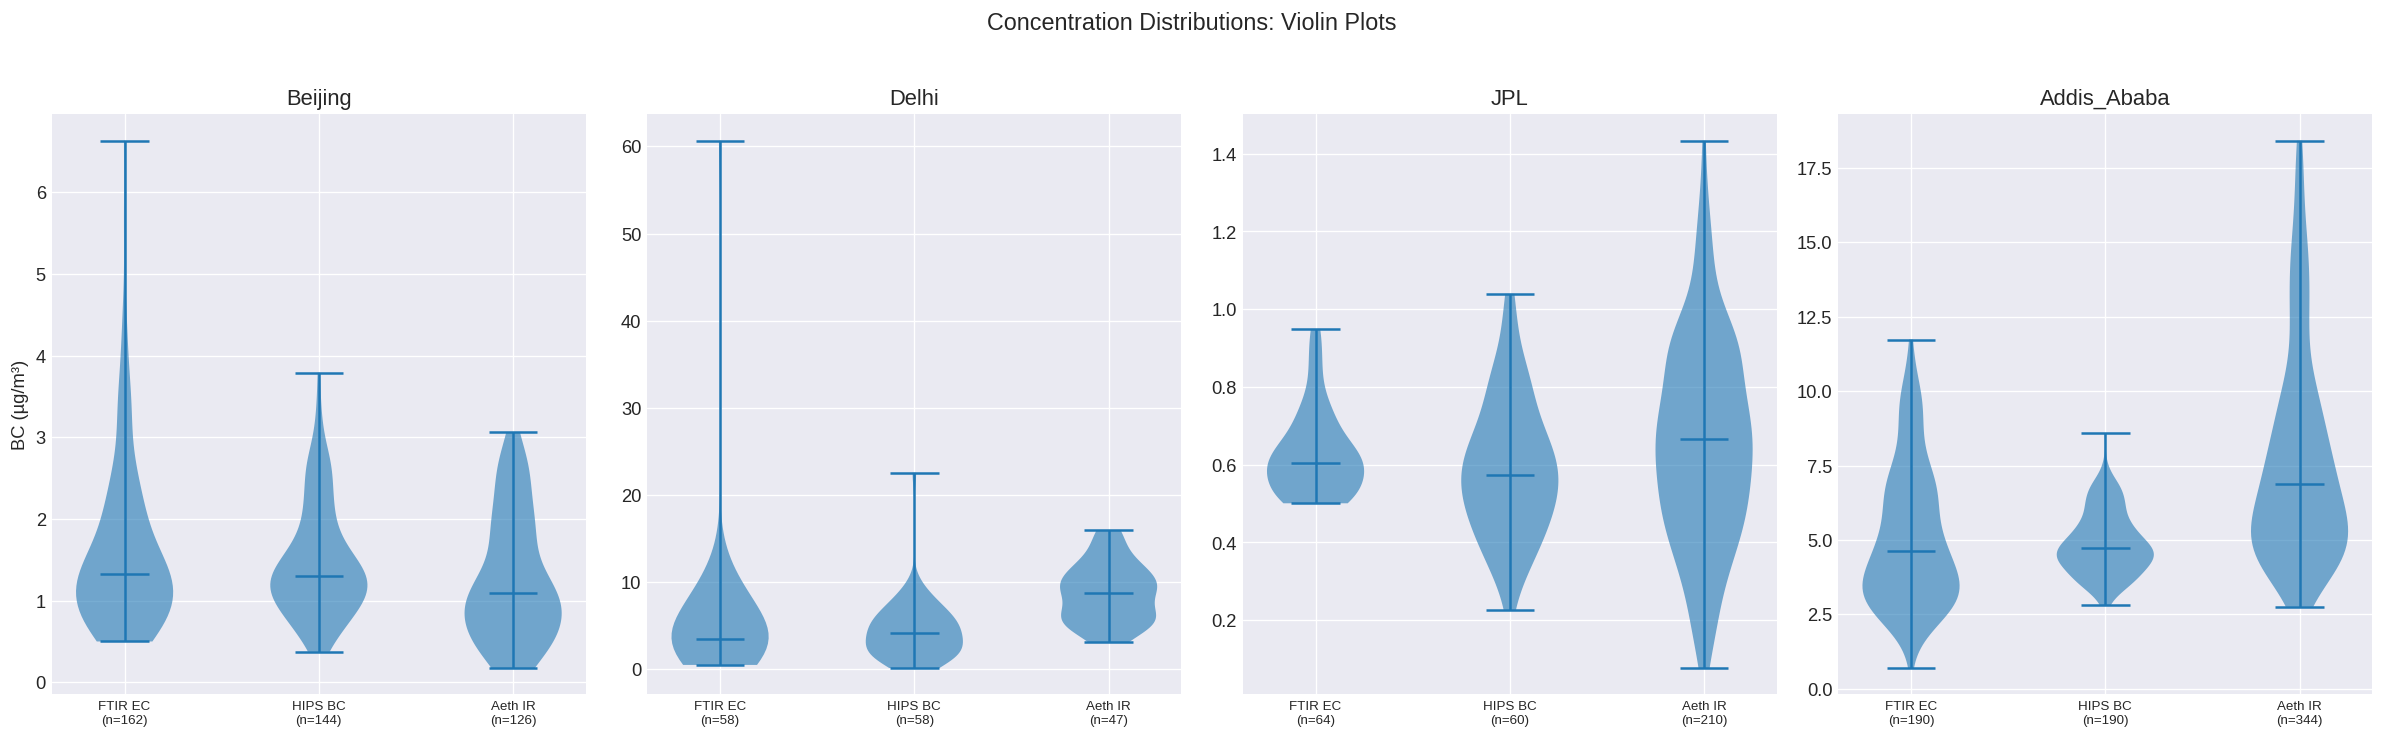

In [4]:
# --- Histograms: side-by-side for each site ---
sites = ['Beijing', 'Delhi', 'JPL', 'Addis_Ababa']
fig, axes = plt.subplots(len(sites), 3, figsize=(18, 5 * len(sites)))

for i, site in enumerate(sites):
    s = filter_clean[filter_clean['SiteName'] == site]
    
    for j, (col, label, color) in enumerate([
        ('EC_ftir', 'FTIR EC (µg/m³)', '#2C3E50'),
        ('HIPS_BC', 'HIPS Fabs/MAC (µg/m³)', '#E74C3C'),
        ('aeth_IR_BCc', 'Aeth IR BCc (µg/m³)', '#3498DB'),
    ]):
        ax = axes[i, j]
        vals = s[col].dropna()
        if len(vals) > 0:
            ax.hist(vals, bins=25, alpha=0.7, color=color, edgecolor='white')
            ax.axvline(vals.median(), color='black', ls='--', lw=2, label=f'median={vals.median():.2f}')
            ax.axvline(vals.mean(), color='red', ls=':', lw=1.5, label=f'mean={vals.mean():.2f}')
            ax.set_title(f'{site} — {label}\n(n={len(vals)}, std={vals.std():.2f})', fontsize=10)
            ax.legend(fontsize=7)
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{site} — {label}', fontsize=10)
        ax.set_xlabel(label if i == len(sites) - 1 else '')

fig.suptitle('Concentration Distributions by Site and Method', fontsize=14, y=1.01)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'distributions_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Violin plots: all methods on one plot per site ---
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

for i, site in enumerate(sites):
    ax = axes[i]
    s = filter_clean[filter_clean['SiteName'] == site]
    
    plot_data = []
    labels = []
    for col, label in [('EC_ftir', 'FTIR EC'), ('HIPS_BC', 'HIPS BC'), ('aeth_IR_BCc', 'Aeth IR')]:
        vals = s[col].dropna().values
        if len(vals) > 3:
            plot_data.append(vals)
            labels.append(f'{label}\n(n={len(vals)})')
    
    if plot_data:
        vp = ax.violinplot(plot_data, showmedians=True, showextrema=True)
        ax.set_xticks(range(1, len(labels) + 1))
        ax.set_xticklabels(labels, fontsize=8)
        for pc in vp['bodies']:
            pc.set_alpha(0.6)
    ax.set_title(site)
    ax.set_ylabel('BC (µg/m³)' if i == 0 else '')

fig.suptitle('Concentration Distributions: Violin Plots', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'distributions_violin.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. AERONET Filtering: Load AOD Data and Apply Sequential Exclusion

Load AERONET Level 1.5 AOD data for Addis (Jacros). Merge with filter data by date. Apply the sequential exclusion: remove days with low AOD (decoupled surface-column days) at 0%, 20%, 40%, 60% thresholds and see how cross-plot relationships change.

In [5]:
# --- Load AERONET Level 1.5 daily AOD ---
aeronet_file = AERONET_DIR / 'daily' / '20220101_20251231_AAU_Jackros_ET.lev15'
aeronet = pd.read_csv(aeronet_file, skiprows=6, na_values=[-999.0, -999])
aeronet['Date'] = pd.to_datetime(aeronet['Date(dd:mm:yyyy)'], format='%d:%m:%Y')

# Key columns
aod_col = 'AOD_500nm'
if aod_col not in aeronet.columns:
    aod_candidates = [c for c in aeronet.columns if 'AOD' in c and '500' in c]
    aod_col = aod_candidates[0] if aod_candidates else None
    
print(f"AERONET daily L1.5: {len(aeronet)} days")
print(f"AOD column: {aod_col}")
print(f"Valid AOD: {aeronet[aod_col].notna().sum()} days")
print(f"AOD range: {aeronet[aod_col].min():.3f} to {aeronet[aod_col].max():.3f}")

# Also load SDA for Fine Mode Fraction
sda_file = AERONET_DIR / 'daily' / '20220101_20251231_AAU_Jackros_ET.ONEILL_lev15'
sda = pd.read_csv(sda_file, skiprows=6, na_values=[-999.0, -999])
sda['Date'] = pd.to_datetime(sda['Date_(dd:mm:yyyy)'], format='%d:%m:%Y')
fmf_col = 'FineModeFraction_500nm[eta]'
print(f"\nSDA daily L1.5: {len(sda)} days, FMF valid: {sda[fmf_col].notna().sum()}")

# Merge AERONET with Addis filter data
addis_filters = filter_wide[filter_wide['SiteName'] == 'Addis_Ababa'].copy()
addis_filters = addis_filters.merge(
    aeronet[['Date', aod_col]].rename(columns={'Date': 'SampleDate', aod_col: 'AOD_500'}),
    on='SampleDate', how='left'
)
addis_filters = addis_filters.merge(
    sda[['Date', fmf_col, 'Total_AOD_500nm[tau_a]', 'Fine_Mode_AOD_500nm[tau_f]',
         'Coarse_Mode_AOD_500nm[tau_c]']].rename(columns={'Date': 'SampleDate'}),
    on='SampleDate', how='left'
)

n_with_aod = addis_filters['AOD_500'].notna().sum()
n_with_ec = (addis_filters['AOD_500'].notna() & addis_filters['EC_ftir'].notna()).sum()
n_with_hips = (addis_filters['AOD_500'].notna() & addis_filters['HIPS_BC'].notna()).sum()
print(f"\nAddis filters with AOD match: {n_with_aod}")
print(f"  With EC+AOD: {n_with_ec}")
print(f"  With HIPS+AOD: {n_with_hips}")

AERONET daily L1.5: 700 days
AOD column: AOD_500nm
Valid AOD: 700 days
AOD range: 0.039 to 0.839

SDA daily L1.5: 700 days, FMF valid: 700

Addis filters with AOD match: 312
  With EC+AOD: 157
  With HIPS+AOD: 157


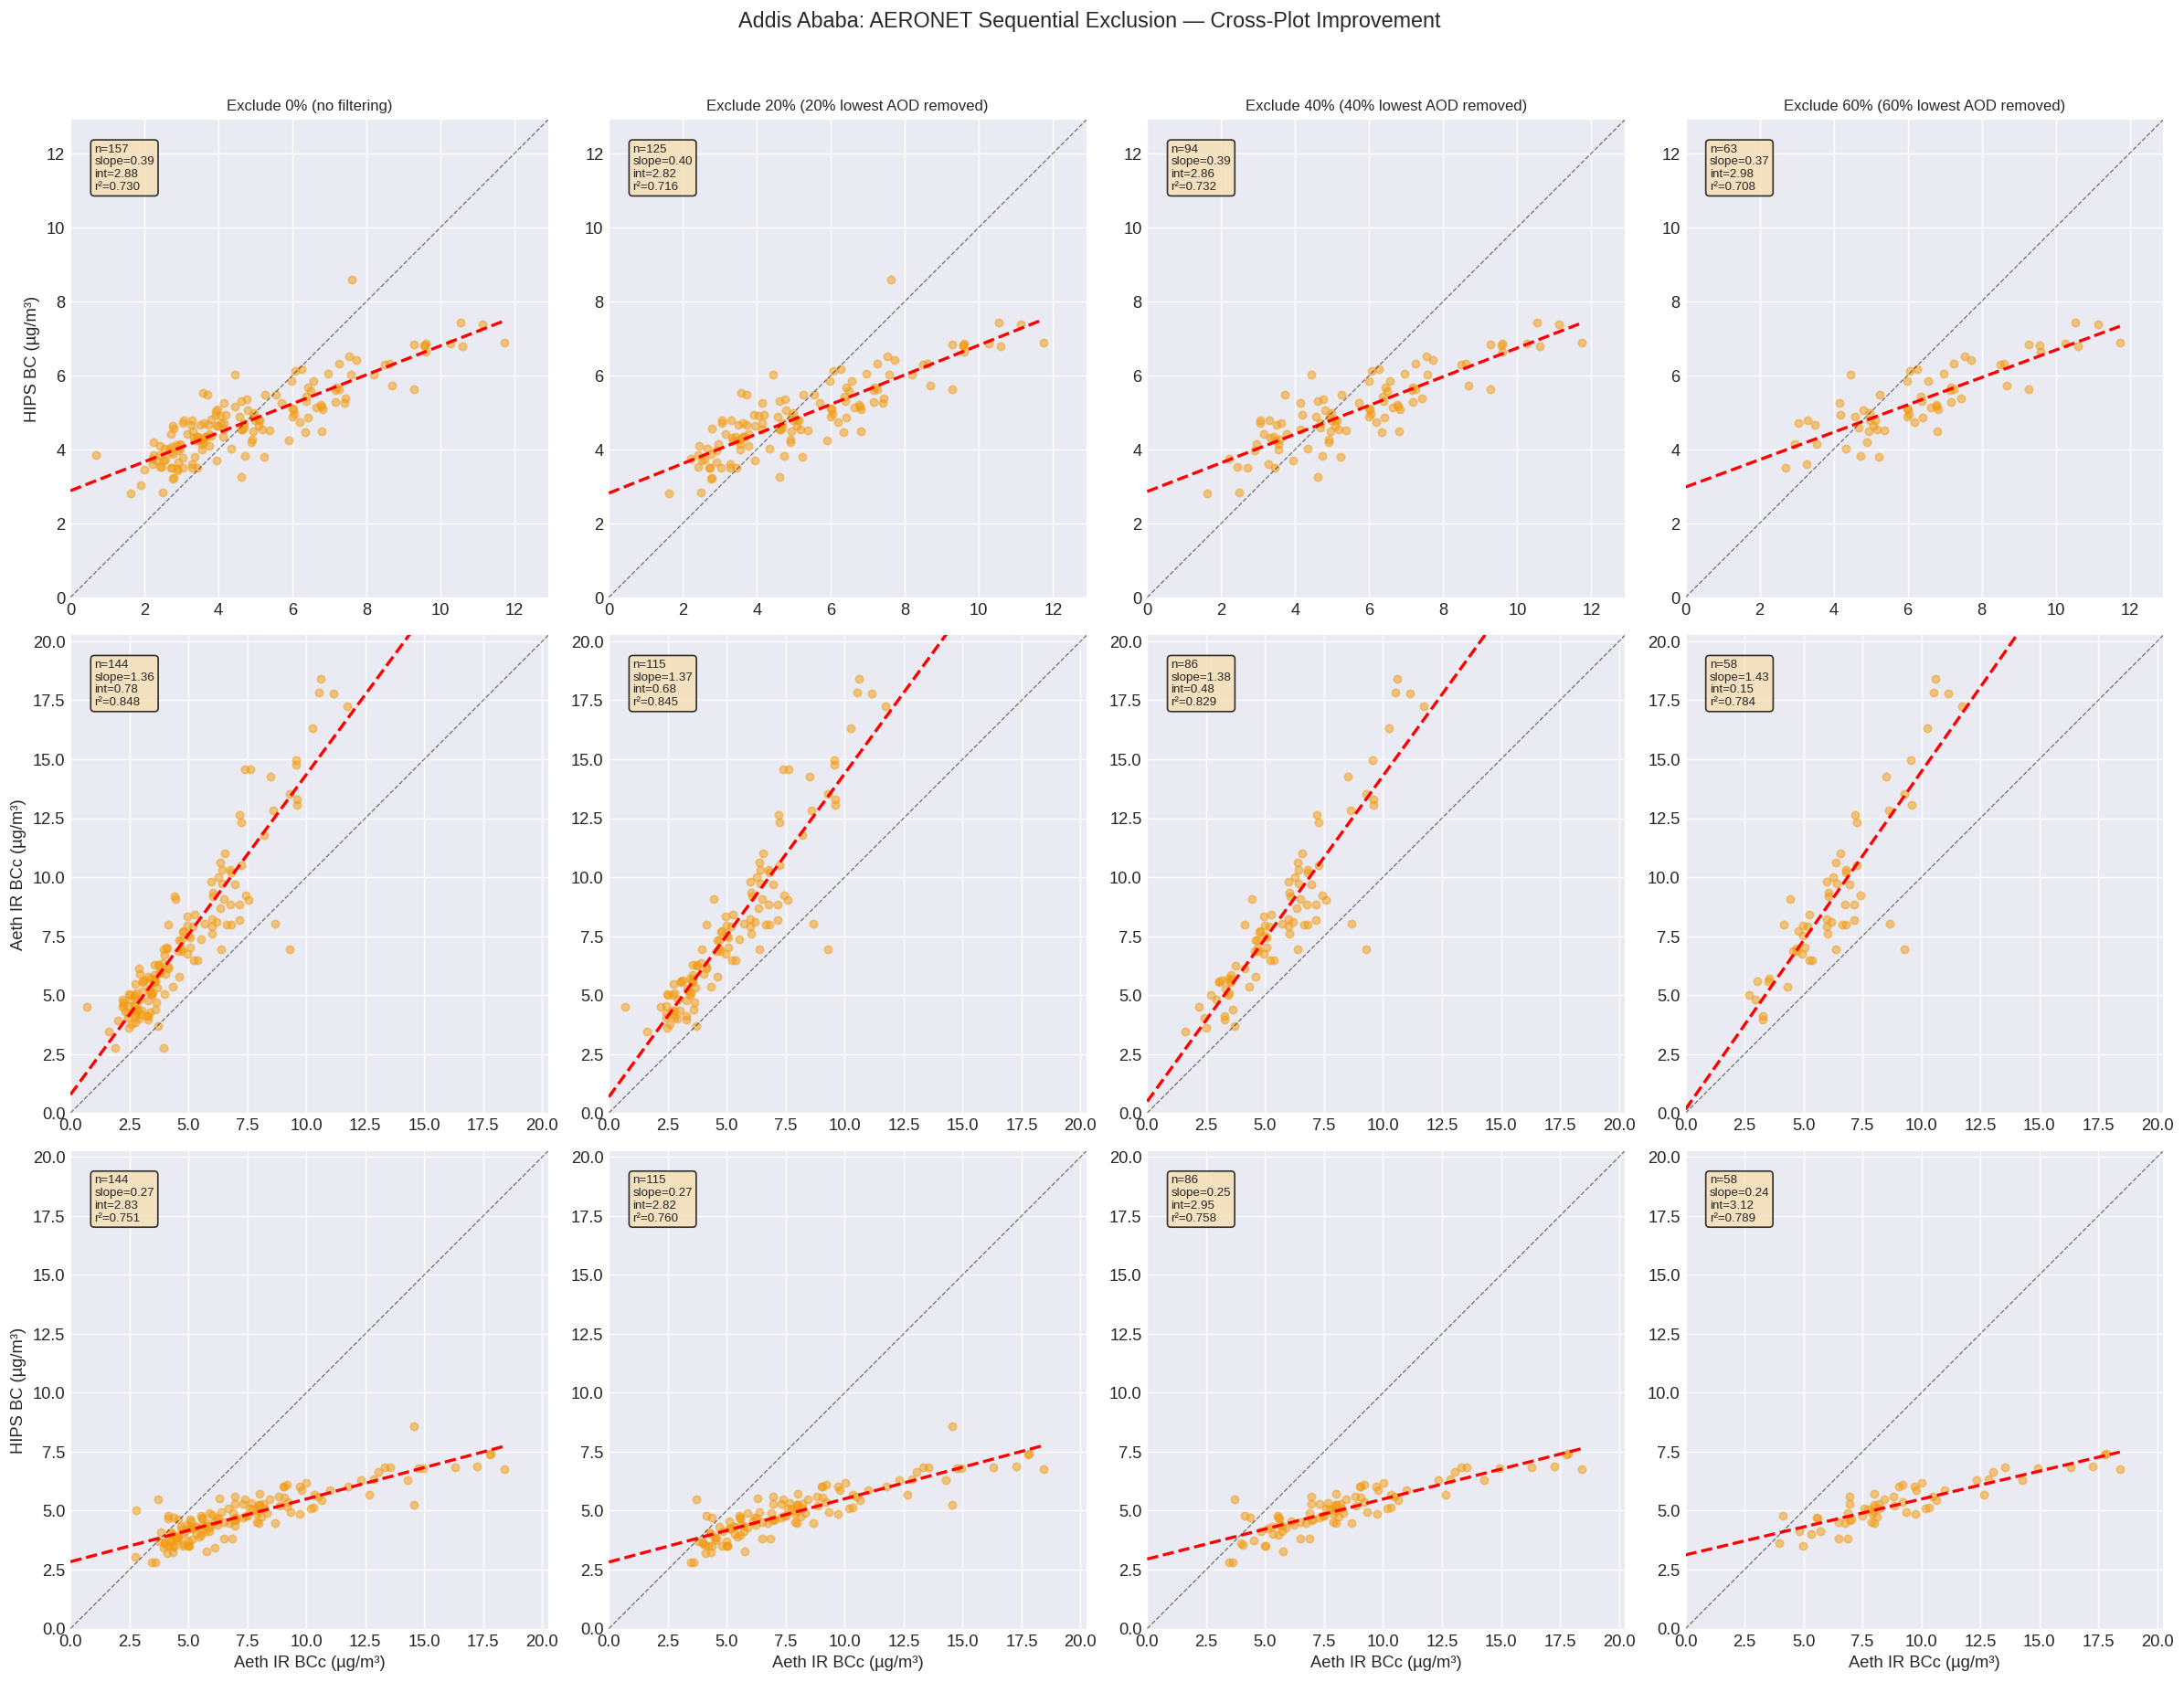


=== AERONET Sequential Exclusion Summary (Addis Ababa) ===



,Comparison,Exclusion %,n,Slope,Intercept,r²
0,HIPS BC vs FTIR EC,0,157,0.392,2.881,0.730
1,HIPS BC vs FTIR EC,20,125,0.400,2.815,0.716
2,HIPS BC vs FTIR EC,40,94,0.388,2.859,0.732
3,HIPS BC vs FTIR EC,60,63,0.370,2.979,0.708
4,Aeth IR BCc vs FTIR EC,0,144,1.357,0.777,0.848
5,Aeth IR BCc vs FTIR EC,20,115,1.371,0.679,0.845
6,Aeth IR BCc vs FTIR EC,40,86,1.381,0.484,0.829
7,Aeth IR BCc vs FTIR EC,60,58,1.432,0.153,0.784
8,HIPS BC vs Aeth IR BCc,0,144,0.266,2.834,0.751
9,HIPS BC vs Aeth IR BCc,20,115,0.268,2.820,0.760


In [6]:
# --- Sequential exclusion: remove lowest AOD percentiles and replot ---
# The idea: low AOD days may indicate decoupled surface-column conditions
# Removing them should improve surface-column agreement

exclusion_pcts = [0, 20, 40, 60]
comparisons = [
    ('EC_ftir', 'HIPS_BC', 'FTIR EC (µg/m³)', 'HIPS BC (µg/m³)'),
    ('EC_ftir', 'aeth_IR_BCc', 'FTIR EC (µg/m³)', 'Aeth IR BCc (µg/m³)'),
    ('aeth_IR_BCc', 'HIPS_BC', 'Aeth IR BCc (µg/m³)', 'HIPS BC (µg/m³)'),
]

fig, axes = plt.subplots(len(comparisons), len(exclusion_pcts), figsize=(5 * len(exclusion_pcts), 5 * len(comparisons)))

summary_rows = []

for row, (x_col, y_col, x_label, y_label) in enumerate(comparisons):
    for col_idx, pct in enumerate(exclusion_pcts):
        ax = axes[row, col_idx]
        
        d = addis_filters.dropna(subset=[x_col, y_col, 'AOD_500']).copy()
        
        if pct > 0 and len(d) > 0:
            threshold = d['AOD_500'].quantile(pct / 100.0)
            d = d[d['AOD_500'] >= threshold]
        
        x, y = d[x_col].values, d[y_col].values
        n = len(x)
        
        ax.scatter(x, y, alpha=0.5, s=25, color=SITE_COLORS['Addis_Ababa'])
        
        if n >= 5:
            slope, intercept, r, p, se = stats.linregress(x, y)
            x_fit = np.linspace(0, max(x.max(), y.max()), 100)
            ax.plot(x_fit, slope * x_fit + intercept, 'r--', lw=2)
            
            lim = max(x.max(), y.max()) * 1.1
            ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.5)
            ax.set_xlim(0, lim)
            ax.set_ylim(0, lim)
            
            ax.text(0.05, 0.95, f'n={n}\nslope={slope:.2f}\nint={intercept:.2f}\nr²={r**2:.3f}',
                    transform=ax.transAxes, fontsize=8, va='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
            
            summary_rows.append({
                'Comparison': f'{y_label.split("(")[0].strip()} vs {x_label.split("(")[0].strip()}',
                'Exclusion %': pct, 'n': n, 'Slope': slope, 'Intercept': intercept, 'r²': r**2
            })
        
        ax.set_xlabel(x_label if row == len(comparisons) - 1 else '')
        ax.set_ylabel(y_label if col_idx == 0 else '')
        if row == 0:
            removed = f' ({pct}% lowest AOD removed)' if pct > 0 else ' (no filtering)'
            ax.set_title(f'Exclude {pct}%{removed}', fontsize=10)
        ax.set_aspect('equal')

fig.suptitle('Addis Ababa: AERONET Sequential Exclusion — Cross-Plot Improvement', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'aeronet_sequential_exclusion.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
summary_df = pd.DataFrame(summary_rows)
print("\n=== AERONET Sequential Exclusion Summary (Addis Ababa) ===\n")
display(summary_df.round(3))

---
## 5. Summary Statistics Table

In [7]:
# --- Summary table: cross-plot statistics per site (unfiltered) ---
rows = []
for site in sites:
    s = filter_clean[filter_clean['SiteName'] == site]
    
    for x_col, y_col, comp_name in [
        ('EC_ftir', 'HIPS_BC', 'HIPS BC vs FTIR EC'),
        ('EC_ftir', 'aeth_IR_BCc', 'Aeth vs FTIR EC'),
        ('aeth_IR_BCc', 'HIPS_BC', 'HIPS BC vs Aeth'),
    ]:
        d = s.dropna(subset=[x_col, y_col])
        if len(d) >= 5:
            x, y = d[x_col].values, d[y_col].values
            slope, intercept, r, p, se = stats.linregress(x, y)
            rows.append({
                'Site': site, 'Comparison': comp_name, 'n': len(d),
                'Slope': slope, 'Intercept': intercept, 'r²': r**2,
                'x_median': np.median(x), 'y_median': np.median(y),
                'x_std': np.std(x), 'y_std': np.std(y),
            })

stats_table = pd.DataFrame(rows)
stats_table.to_csv(PLOT_DIR / 'crossplot_statistics.csv', index=False)
print("Cross-plot statistics (unfiltered):")
display(stats_table.round(3))

Cross-plot statistics (unfiltered):


,Site,Comparison,n,Slope,Intercept,r²,x_median,y_median,x_std,y_std
0,Beijing,HIPS BC vs FTIR EC,144,0.603,0.539,0.663,1.294,1.296,0.928,0.687
1,Beijing,Aeth vs FTIR EC,58,0.551,0.409,0.509,1.369,1.135,0.975,0.753
2,Beijing,HIPS BC vs Aeth,58,0.779,0.509,0.754,1.135,1.312,0.753,0.676
3,Delhi,HIPS BC vs FTIR EC,58,0.384,2.354,0.789,3.516,4.165,7.904,3.414
4,Delhi,Aeth vs FTIR EC,23,0.943,2.301,0.547,6.077,8.752,2.650,3.377
5,Delhi,HIPS BC vs Aeth,23,0.484,2.057,0.915,8.752,6.214,3.377,1.708
6,JPL,HIPS BC vs FTIR EC,60,0.842,0.057,0.295,0.613,0.574,0.111,0.172
7,JPL,Aeth vs FTIR EC,40,1.271,-0.020,0.306,0.599,0.782,0.099,0.228
8,JPL,HIPS BC vs Aeth,40,0.602,0.141,0.761,0.782,0.621,0.228,0.157
9,Addis_Ababa,HIPS BC vs FTIR EC,190,0.402,2.832,0.764,4.625,4.713,2.304,1.061
